# scATAC-seq preprocessing and quality control

`omicverse.epi` (`ov.epi`) brings **epigenomics** into OmicVerse by wrapping the
[epione](https://github.com/aristoteleo/epione) toolkit. Every `ov.epi` function imports
epione internally and delegates, so the familiar `pp` / `tl` / `pl` layout you know from the
rest of OmicVerse now also covers single-cell ATAC-seq, bulk ATAC/ChIP, footprinting,
chromVAR motif activity, peak-to-gene linkage and Hi-C.

This first tutorial walks the **upstream half** of a single-cell ATAC-seq analysis — turning a
10x `fragments.tsv.gz` into a quality-controlled cell × tile matrix ready for embedding:

1. ingest a fragments file (`ov.epi.pp.import_fragments`)
2. compute per-cell QC metrics — TSS enrichment, fragment-size periodicity, nucleosome signal
3. filter low-quality cells (`ov.epi.pp.qc`)
4. build a 500 bp genome-tile count matrix and select features
5. a first iterative-LSI embedding to sanity-check the result

We use the public **10x PBMC 500-cell** scATAC dataset (GRCh38), which `ov.epi.datasets`
downloads on demand — so the whole notebook is self-contained and runs on a laptop CPU.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import omicverse as ov

# Confirm the epione backend is available and apply the publication plot style.
ov.epi.check_epione()
ov.epi.pl.plot_set()
print('omicverse', ov.__version__)

epione is available (version 0.0.1rc1); ov.epi is ready.
└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

omicverse 2.2.1rc1


## 1 · Load fragments

`ov.epi.datasets.atac_pbmc500_fragments()` fetches (and caches) the bgzipped, tabix-indexed
10x PBMC-500 fragments file. `ov.epi.pp.import_fragments` scans it into an AnnData carrying
per-cell QC counts. We pass `file=` so the object is written out-of-memory (anndataoom-backed) —
this is what lets the genome-wide tile matrix be added later without blowing up RAM.

The chromosome sizes / gene annotation come from `ov.epi.data.hg38`, a reference `Genome`
that lazily downloads the GRCh38 FASTA + Gencode annotation via pooch on first use.

In [2]:
import os

frag = ov.epi.datasets.atac_pbmc500_fragments()
print('fragments file:', frag)

genome = ov.epi.data.hg38

work = os.path.join(os.getcwd(), 'data_epi')
os.makedirs(work, exist_ok=True)
h5 = os.path.join(work, 'pbmc500.h5ad')
if os.path.exists(h5):
    os.remove(h5)

adata = ov.epi.pp.import_fragments(
    str(frag),
    chrom_sizes=genome,
    file=h5,
    min_num_fragments=500,
)
adata

fragments file: /tmp/snapatac2/atac_pbmc_500.tsv.gz
└─ scanning /tmp/snapatac2/atac_pbmc_500.tsv.gz


  └─ imported 646 cells  (9,899,673 unique fragments)


name,dtype,preview
n_fragment,int64,"8964, 14968, 28335, … (639)"
frac_dup,float64,"0.6372172083046663, 0.6288986958893241, 0.7626347666557765, … (645)"
frac_mito,float64,0.0


## 2 · Per-cell quality-control metrics

Three complementary QC signals tell us which barcodes are real, high-quality cells:

- **TSS enrichment** (`tsse`) — accessibility pile-up at transcription start sites vs. flanking
  background. High-quality ATAC sits well above 2–4.
- **Fragment-size distribution** — open chromatin shows a clean nucleosome ladder (a sub-100 bp
  nucleosome-free peak, then mono-/di-nucleosome shoulders at ~200/400 bp).
- **Nucleosome signal** — ratio of mono-nucleosome to nucleosome-free fragments per cell.

The TSS step needs gene coordinates, which we read from the bundled hg38 annotation.

In [3]:
genes = ov.epi.io.get_gene_annotation(genome)
print('gene annotation rows:', len(genes))

ov.epi.pp.tsse(adata, genes)
ov.epi.pp.frag_size_distr(adata)
ov.epi.pp.nucleosome_signal(adata)

# obs is a lazy on-disk element on the backed object; pull it into pandas for inspection.
obs = ov.epi.utils.obs_to_pandas(adata)
obs[['n_fragment', 'tsse', 'nucleosome_signal']].head()

gene annotation rows: 19978
└─ Computing TSS enrichment score for adata...
└─ Computing TSS enrichment score for adata...


Fetching Regions...:   0%|                                                                                        | 0/19978 [00:00<?, ?it/s]

Fetching Regions...:   0%|▎                                                                             | 96/19978 [00:00<00:21, 946.38it/s]

Fetching Regions...:   1%|▉                                                                           | 235/19978 [00:00<00:16, 1198.60it/s]

Fetching Regions...:   2%|█▍                                                                          | 363/19978 [00:00<00:15, 1233.54it/s]

...

Reading Fragments:  99%|█████████████████████████████████████████████████████████████████████▍| 6412347/6460000 [00:15<00:00, 419637.26it/s]

Reading Fragments: 100%|█████████████████████████████████████████████████████████████████████▉| 6454312/6460000 [00:15<00:00, 419428.07it/s]

Reading Fragments: 100%|██████████████████████████████████████████████████████████████████████| 6460000/6460000 [00:15<00:00, 420231.64it/s]

  └─ Added a "nucleosome_signal" column to the .obs slot of the AnnData object
└─ Created nucleosome signal
  └─ Added nucleosome signal to adata.obs['nucleosome_signal']


,n_fragment,tsse,nucleosome_signal
obs_names,,,
AAACTGCAGACTCGGA-1,8964,27.805281,0.572474
AAAGATGCACCTATTT-1,14968,25.742574,0.491104
AAAGATGCAGATACAA-1,28335,39.995482,0.456936
AAAGGGCTCGCTCTAC-1,28541,25.804671,0.719165
AAATGAGAGTCCCGCA-1,7749,37.316490,0.425304


### Fragment-size periodicity

The nucleosome ladder is one of the cleanest ATAC QC signatures. `ov.epi.pl.frag_size_distr`
plots the distribution computed above; the log-y view makes the di-nucleosome shoulder visible.

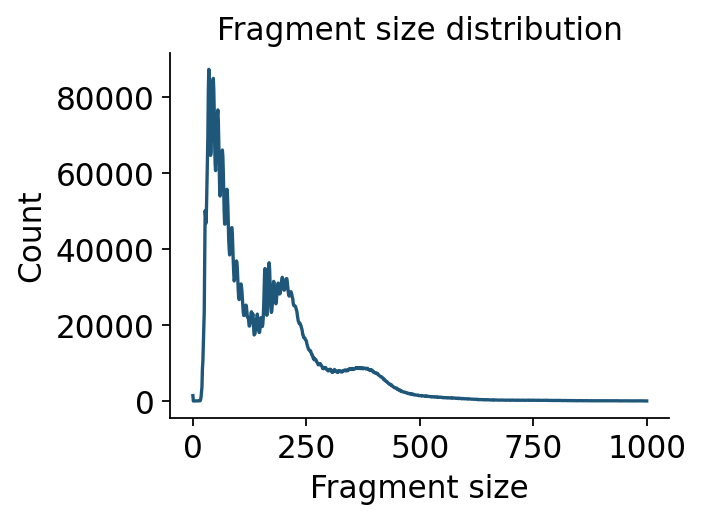

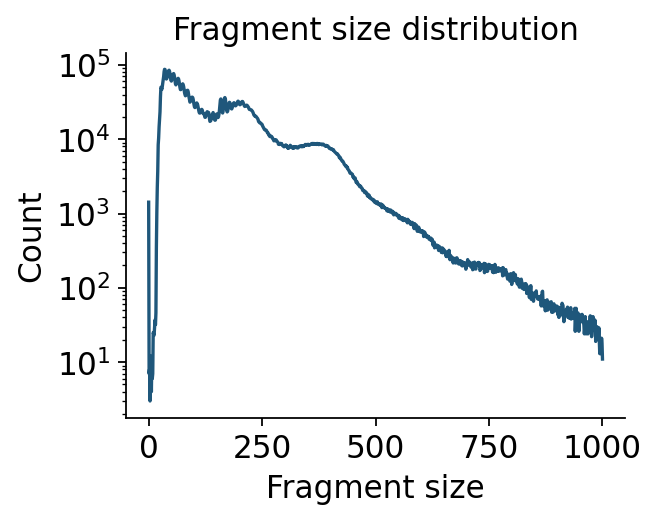

In [4]:
ov.epi.pl.frag_size_distr(adata, figsize=(4, 3))
plt.show()
ov.epi.pl.frag_size_distr(adata, figsize=(4, 3), log_y=True)
plt.show()

### Joint QC scatter

A log-fragment-count vs. TSS-enrichment scatter is the classic ATAC QC view: good cells sit in
the upper-right (high coverage **and** high TSS enrichment).

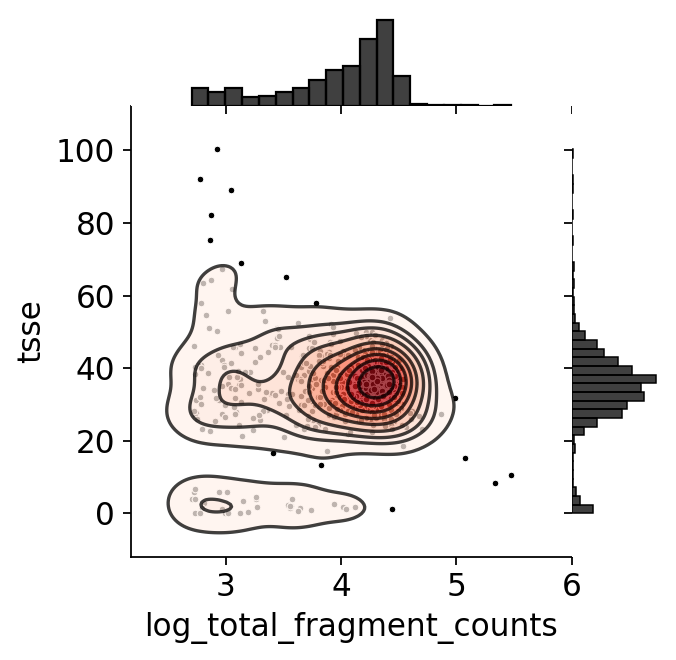

In [5]:
# Joint QC scatter via epione's ATAC-native plotter (log-fragments vs TSSe).
obs['log_total_fragment_counts'] = np.log10(obs['n_fragment'])
ov.epi.pl.plot_joint(adata, x_col='log_total_fragment_counts', y_col='tsse',
                     kde_kwargs={'cut': 3})
plt.show()

## 3 · Filter low-quality cells

`ov.epi.pp.qc` applies thresholds on all metrics at once. We keep cells with 1000–100000
fragments, TSS enrichment ≥ 2 and nucleosome signal ≤ 4.

In [6]:
adata = ov.epi.pp.qc(adata, tresh={
    'fragment_counts_min': 1000,
    'fragment_counts_max': 100000,
    'TSS_score_min':       2.0,
    'TSS_score_max':       100.0,
    'Nucleosome_singal_max': 4.0,
})
print('cells passing QC:', adata.n_obs)
adata

└─ Performing QC...
  └─ Filtering cells based on fragment counts...
  └─ Filtering cells based on nucleosome signal...
  └─ Filtered 78 cells
cells passing QC: 568


name,dtype,preview
n_fragment,int64,"8964, 14968, 28335, … (565)"
frac_dup,float64,"0.6372172083046663, 0.6288986958893241, 0.7626347666557765, … (568)"
frac_mito,float64,0.0
tss_score,float64,"27.805280528052805, 25.742574257425744, 39.995482437977635, … (560)"
tsse,float64,"27.805280528052805, 25.742574257425744, 39.995482437977635, … (560)"
nucleosome_signal,float64,"0.5724738675958189, 0.4911038836808877, 0.4569364161849711, … (568)"
log_total_fragment_counts,float64,"3.9525018478630236, 4.175163774491954, 4.452323216977515, … (565)"
selected,bool,True


## 4 · Tile matrix and feature selection

For unbiased clustering we bin the genome into 500 bp tiles and count per-cell insertions
(`add_tile_matrix`), then keep the most-accessible features (`select_features`).

In [7]:
ov.epi.pp.add_tile_matrix(adata, bin_size=500)
ov.epi.pp.select_features(adata, n_features=250000)
print('tile matrix:', adata.shape)
print('features selected:', int(np.asarray(adata.var['selected']).sum()))

└─ building tile matrix: 568 cells × 6,176,584 tiles (500 bp bins, strategy=paired-insertion)


  └─ tile matrix nnz=9,644,952


└─ Selected 250,000 features.
tile matrix: (568, 6176584)


features selected: 250000


## 5 · A first embedding

ArchR-style **iterative LSI** (`ov.epi.tl.iterative_lsi`) is the standard scATAC dimensionality
reduction: binarize → TF-IDF → SVD, iterated with intermediate clustering to focus on
variable features. We then build a neighbor graph, cluster and embed with UMAP — the same
`pp`/`tl` verbs as the RNA workflow.

In [8]:
ov.epi.tl.iterative_lsi(adata, n_components=20, iterations=2)
ov.epi.pp.neighbors(adata, use_rep='X_iterative_lsi')
ov.epi.tl.clusters(adata, method='leiden', use_rep='X_iterative_lsi', key_added='clusters')
ov.epi.tl.umap(adata)
print('embeddings:', list(adata.obsm.keys()))

  └─ [iterative_lsi] Initial feature set: 500,000 / 6,176,584
  └─ [iterative_lsi] Iter 1/2 | fit on 568 cells x 500,000 features


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)


running Leiden clustering


    finished: found 7 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


  └─ [iterative_lsi]   -> 7 clusters; selected 25,000 variable features for next round
  └─ [iterative_lsi] Iter 2/2 | fit on 568 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (568 x 19) in adata.obsm['X_iterative_lsi']
Computing neighbors with n_neighbors=15


Finished computing neighbors
    Added to .uns['neighbors']
    .obsp['distances'], distances for each pair of neighbors
    .obsp['connectivities'], weighted adjacency matrix
Running Leiden clustering with leidenalg...
    Finished: found 9 clusters
    Added 'clusters' to adata.obs (categorical)
Computing UMAP embedding...


    Finished computing UMAP
    Added:
        'X_umap', UMAP coordinates (adata.obsm)
        'umap', UMAP parameters (adata.uns)
embeddings: ['X_iterative_lsi', 'X_umap']


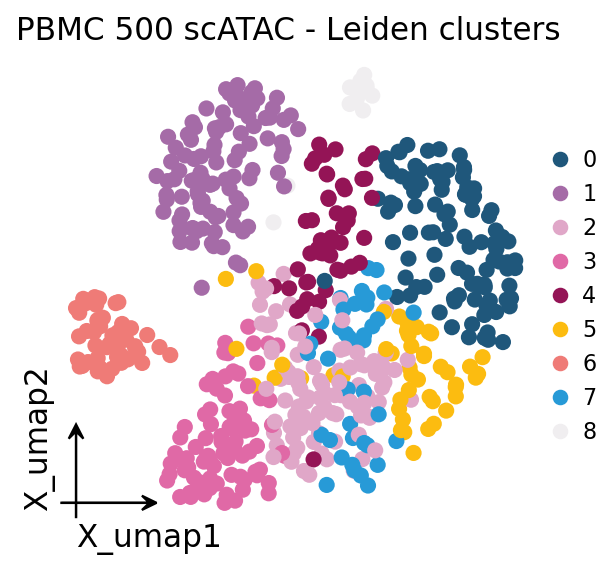

In [9]:
# Plot the embedding with omicverse's standard plotter. The QC AnnData is
# anndataoom-backed, so we wrap the UMAP + cluster labels in a light in-memory
# AnnData for ov.pl.embedding.
import anndata as ad
obs = ov.epi.utils.obs_to_pandas(adata)
pa = ad.AnnData(np.zeros((adata.n_obs, 1), dtype='float32'))
pa.obs_names = list(adata.obs_names)
pa.obs['clusters'] = obs['clusters'].astype('category').values
pa.obsm['X_umap'] = np.asarray(adata.obsm['X_umap'])
ov.pl.embedding(pa, basis='X_umap', color='clusters', frameon='small',
                title='PBMC 500 scATAC - Leiden clusters', show=False)
plt.show()

## Summary

Starting from a raw 10x fragments file we produced a QC-filtered, embedded scATAC dataset using
only `ov.epi`:

| stage | function |
|---|---|
| ingest fragments | `ov.epi.pp.import_fragments` |
| TSS enrichment | `ov.epi.pp.tsse` |
| fragment size / nucleosome | `ov.epi.pp.frag_size_distr`, `ov.epi.pp.nucleosome_signal` |
| QC filter | `ov.epi.pp.qc` |
| tile matrix / features | `ov.epi.pp.add_tile_matrix`, `ov.epi.pp.select_features` |
| embed / cluster | `ov.epi.tl.iterative_lsi`, `ov.epi.pp.neighbors`, `ov.epi.tl.clusters`, `ov.epi.tl.umap` |

The next tutorial picks up from a larger annotated PBMC dataset to cover **clustering, cell-type
annotation and gene-activity scores**.